# The Hessian

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture on the **Hessian**
(Week 3 — Optimization in Neural Networks and Newton's Method).

This notebook explains:

- the second derivative in **many variables** — a matrix of second partials, the **Hessian**
- the comparison: $f' \to$ gradient $\nabla f$, and $f'' \to$ Hessian $H$
- the worked example $f(x,y) = 2x^2 + 3y^2 - xy$ and its four second partials
- why the **mixed partials are equal** ($f_{xy} = f_{yx}$, Clairaut's theorem)
- the Hessian matrix, its notation, and a SymPy computation
- a preview of how it classifies critical points (convexity)

This notebook follows the repository `GUIDELINES.md` template and continues directly from
*The Second Derivative*.

## 1. From one variable to many

| | one variable $f(x)$ | two variables $f(x,y)$ |
|---|---|---|
| first derivative | $f'(x)$ | gradient $\nabla f = (f_x, f_y)$ |
| second derivative | $f''(x)$ | **Hessian** $H$ (a matrix) |

With one variable there is a single rate of change; with two there are two
($f_x, f_y$), collected in the **gradient**. For the *second* derivative, two variables give
**four** second partials, collected in the **Hessian matrix**.

## 2. Worked example

Take

$$
f(x,y) = 2x^2 + 3y^2 - xy .
$$

**First partials:**

$$
f_x = 4x - y, \qquad f_y = 6y - x .
$$

**Second partials** — differentiate each first partial with respect to each variable:

$$
f_{xx} = \frac{\partial}{\partial x}(4x - y) = 4, \qquad
f_{xy} = \frac{\partial}{\partial y}(4x - y) = -1,
$$
$$
f_{yx} = \frac{\partial}{\partial x}(6y - x) = -1, \qquad
f_{yy} = \frac{\partial}{\partial y}(6y - x) = 6 .
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

x, y = sp.symbols('x y')
f = 2*x**2 + 3*y**2 - x*y

fx, fy = sp.diff(f, x), sp.diff(f, y)
print("f_x =", fx, "   f_y =", fy)

fxx = sp.diff(f, x, x); fxy = sp.diff(f, x, y)
fyx = sp.diff(f, y, x); fyy = sp.diff(f, y, y)
print(f"f_xx = {fxx},  f_xy = {fxy}")
print(f"f_yx = {fyx},  f_yy = {fyy}")

f_x = 4*x - y    f_y = -x + 6*y
f_xx = 4,  f_xy = -1
f_yx = -1,  f_yy = 6


## 3. The mixed partials are equal

Notice $f_{xy} = f_{yx} = -1$. This is not a coincidence:

> *"When both partial derivatives are differentiable, the derivative with respect to $x$ of
> the derivative with respect to $y$ is the same as the derivative with respect to $y$ of
> the derivative with respect to $x$."*

This is **Clairaut's (Schwarz's) theorem**. It means the Hessian is **symmetric**.

**Notation.** Leibniz: $\dfrac{\partial^2 f}{\partial x^2}, \dfrac{\partial^2 f}{\partial y^2},
\dfrac{\partial^2 f}{\partial x\,\partial y}, \dfrac{\partial^2 f}{\partial y\,\partial x}$.
Lagrange: $f_{xx}, f_{yy}, f_{xy}, f_{yx}$.

In [2]:
print("mixed partials equal? f_xy == f_yx :", sp.simplify(fxy - fyx) == 0)

mixed partials equal? f_xy == f_yx : True


## 4. The Hessian matrix

Arrange the four second partials into a matrix:

$$
H = \begin{bmatrix} f_{xx} & f_{xy} \\ f_{yx} & f_{yy} \end{bmatrix}
  = \begin{bmatrix} 4 & -1 \\ -1 & 6 \end{bmatrix}.
$$

In general, for $f(x,y)$,

$$
H = \begin{bmatrix}
\dfrac{\partial^2 f}{\partial x^2} & \dfrac{\partial^2 f}{\partial x\,\partial y} \\[2mm]
\dfrac{\partial^2 f}{\partial y\,\partial x} & \dfrac{\partial^2 f}{\partial y^2}
\end{bmatrix}.
$$

In [3]:
# SymPy has a built-in hessian
H = sp.hessian(f, (x, y))
print("Hessian of f =")
sp.pprint(H)

Hessian of f =
⎡4   -1⎤
⎢      ⎥
⎣-1  6 ⎦


## 5. Why the Hessian matters (preview)

The Hessian is the multivariable analogue of $f''$, so it plays the same role in
**optimization**:

- it appears in **multivariable Newton's method** (next lecture),
- and it **classifies critical points** — the higher-dimensional version of the
  second-derivative test, using whether $H$ is **positive definite** (a bowl → minimum),
  **negative definite** (a dome → maximum), or indefinite (a saddle).

For our $f$, the Hessian is constant. Its eigenvalues tell us the shape.

Hessian eigenvalues: [3.5858 6.4142]
both positive -> positive definite -> the surface is a convex bowl (minimum).


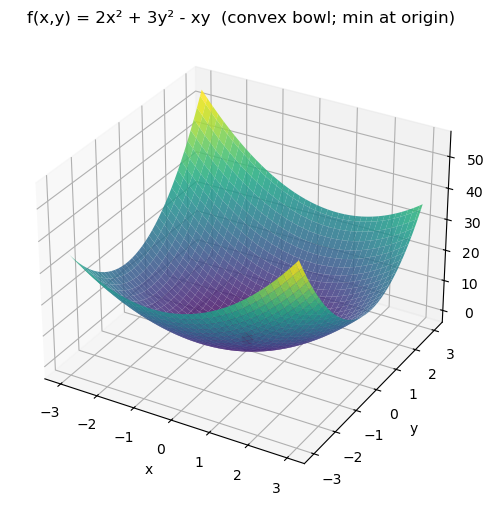

In [4]:
Hn = np.array([[4, -1], [-1, 6]], dtype=float)
eig = np.linalg.eigvalsh(Hn)
print("Hessian eigenvalues:", np.round(eig, 4))
print("both positive -> positive definite -> the surface is a convex bowl (minimum).")

# the surface
gx = np.linspace(-3, 3, 80); gy = np.linspace(-3, 3, 80)
X, Y = np.meshgrid(gx, gy)
Z = 2*X**2 + 3*Y**2 - X*Y

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, Z, cmap="viridis", alpha=0.85)
ax.scatter([0], [0], [0], color="red", s=60)
ax.set_title("f(x,y) = 2x² + 3y² - xy  (convex bowl; min at origin)")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("f")
plt.show()

## 6. Exercises

### Basic
1. What object is the second derivative of a function of two variables?
2. Write the general Hessian matrix for $f(x,y)$.

### Intermediate
3. Compute the Hessian of $f(x,y) = 2x^2 + 3y^2 - xy$ by hand and check $f_{xy} = f_{yx}$.
4. Compute the Hessian of $g(x,y) = x^2 y$ (note: it is **not** constant).

### Advanced
5. For $h(x,y) = x^2 + y^2$, find the Hessian and its eigenvalues; what shape is the
   surface?
6. State the condition under which $f_{xy} = f_{yx}$ is guaranteed.

## 7. Solutions / Checks

In [5]:
x, y = sp.symbols('x y')

# 3.
f = 2*x**2 + 3*y**2 - x*y
print("3. Hessian:"); sp.pprint(sp.hessian(f, (x, y)))
print("   f_xy == f_yx:", sp.diff(f, x, y) == sp.diff(f, y, x))

# 4.
g = x**2 * y
print("4. Hessian of x²y:"); sp.pprint(sp.hessian(g, (x, y)))

# 5.
h = x**2 + y**2
Hh = np.array(sp.hessian(h, (x, y))).astype(float)
print("5. Hessian of x²+y²:", Hh.tolist(), "eigenvalues:", np.linalg.eigvalsh(Hh).tolist(),
      "-> convex bowl (min).")

print("6. f_xy = f_yx when both partial derivatives are differentiable (Clairaut/Schwarz).")

3. Hessian:
⎡4   -1⎤
⎢      ⎥
⎣-1  6 ⎦
   f_xy == f_yx: True
4. Hessian of x²y:


⎡2⋅y  2⋅x⎤
⎢        ⎥
⎣2⋅x   0 ⎦
5. Hessian of x²+y²: [[2.0, 0.0], [0.0, 2.0]] eigenvalues: [2.0, 2.0] -> convex bowl (min).
6. f_xy = f_yx when both partial derivatives are differentiable (Clairaut/Schwarz).


## 8. Conclusion

- For a function of several variables the second derivative is a **matrix** — the
  **Hessian** — holding all second partial derivatives.
- For $f(x,y)$:
  $H = \begin{bmatrix} f_{xx} & f_{xy} \\ f_{yx} & f_{yy} \end{bmatrix}$, e.g.
  $\begin{bmatrix} 4 & -1 \\ -1 & 6 \end{bmatrix}$ for $2x^2 + 3y^2 - xy$.
- It is **symmetric** because the mixed partials are equal (Clairaut's theorem).
- The Hessian is the multivariable $f''$: it powers **Newton's method in many variables** and
  classifies critical points via its definiteness — the next topics.

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/index (1).mp4`), the Coursera *Calculus for Machine Learning and Data
Science* (Week 3) lecture on **the Hessian**. Key spoken points, lightly cleaned:

> For multiple variables, the second derivative is a matrix of second derivatives called the
> Hessian, used in multivariable Newton's method. A one-variable function has one rate of
> change $f'$; a two-variable function has two, $f_x$ and $f_y$, forming the gradient
> $\nabla f$. The second derivative: one variable gives $f''$, two variables give the
> Hessian. Example: $f(x,y) = 2x^2 + 3y^2 - xy$ has $f_x = 4x - y$, $f_y = 6y - x$; the
> second partials are $f_{xx} = 4$, $f_{xy} = -1$, $f_{yx} = -1$, $f_{yy} = 6$. The two
> mixed partials are the same (when both partials are differentiable) — Clairaut's theorem.
> Arranging them gives the Hessian $\begin{bmatrix} 4 & -1 \\ -1 & 6 \end{bmatrix}$, which
> carries a lot of information and is very useful in optimization.